In [8]:
import sys
import os
curr_dir=os.getcwd()
ROOT_DIR = os.path.abspath(os.path.join(curr_dir, os.pardir, os.pardir))
print(f"Root directory: {ROOT_DIR}")
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

from liset_tk.liset_paper import liset_paper
import numpy as np
import matplotlib.pyplot as plt
from snnTorch.raster.utils import calculate_threshold, up_down_channel, extract_spikes_downsample
from snnTorch.raster.process_signal import spikify_signal
from liset_tk.signal_aid import bandpass_filter
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

Root directory: c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples


In [2]:
parent=r"C:\PedroFelix\Download_from_paper"
datasets=os.listdir(parent)
dataset=2
dataset_path=os.path.join(parent,datasets[dataset])
print(f"Processing dataset: {datasets[dataset]}")

Processing dataset: Som2_2019-07-24_12-01-49


In [3]:
liset=liset_paper(dataset_path, shank=1, downsample=False, start=0, verbose=False)

In [22]:
def plot_offline_detections(liset,ch=None, offset=0, filtered=None, extend=0.5, title='Overview', window=None, plot_offline=True,plot_light=True,plot_predicted=True):
    """
    Plot data with overlays for:
    - Ground truth ripples (yellow)
    - Model predicted ripples (blue)
    - Light stimulation TTLs (red)

    Parameters
    ----------
    ch : int or list of ints, optional
        Channel(s) to plot. If None, plots the first channel.
    offset : float, optional
        Vertical offset between channels.
    filtered : tuple (low, high), optional
        Bandpass filter range (Hz).
    extend : float, optional
        Extra context (in seconds) around each event.
    title : str, optional
        Title for the plot.
    window : tuple (start, end), optional
        Time window in seconds to plot (e.g., (10, 20)).
    """

    # ---------------------
    # Select channels
    # ---------------------
    if ch is None:
        ch = [0]
    elif isinstance(ch, int):
        ch = [ch]

    n_samples = liset.data.shape[0]
    time = np.arange(n_samples) / liset.fs

    # ---------------------
    # Apply time window
    # ---------------------
    if window is not None:
        start_s, end_s = window
        start_idx = int(start_s * liset.fs)
        end_idx = int(end_s * liset.fs)
        time = time[start_idx:end_idx]
        data_slice = liset.data[start_idx:end_idx, :]
    else:
        data_slice = liset.data

    fig, ax = plt.subplots(figsize=(15, 6))
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude [z-score]")

    # ---------------------
    # Plot data (optionally filtered)
    # ---------------------
    for i, ch_idx in enumerate(ch):
        sig = deepcopy(data_slice[:, ch_idx])
        if filtered:
            sig = bandpass_filter(sig, filtered, liset.fs)

        ax.plot(time, sig + i * offset, color="black", lw=1.2, label=f"Ch {ch_idx}" if i == 0 else "")

    min_y, max_y = ax.get_ylim()

    # ---------------------
    # Helper function to plot intervals safely within window
    # ---------------------
    def plot_intervals(intervals, color, label):
        if window is not None:
            mask = (intervals[:, 1] / liset.fs > start_s) & (intervals[:, 0] / liset.fs < end_s)
            intervals = intervals[mask]
        for i, r in enumerate(intervals):
            ax.fill_between(r / liset.fs, min_y, max_y, color=color, alpha=0.3, label=label if i == 0 else "")

    # ---------------------
    # Ground truth ripples (yellow)
    # ---------------------
    if hasattr(liset, "ripples_GT") and liset.ripples_GT is not None:
        plot_intervals(liset.ripples_GT, "yellow", "Ground truth")
    # ---------------------
    # Beautify
    # ---------------------
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys())
    ax.set_xlim(min(time), max(time))
    ax.set_ylim(min_y, max_y)
    # ax.grid(False, linestyle='--', alpha=0.3)
    ax.grid(False)
    ax.tick_params(axis='both', which='major',labelsize=14,width=1.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.spines['bottom'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.3)
    ax.spines['left'].set_linewidth(1.3)
    plt.tight_layout()
    plt.show()
    

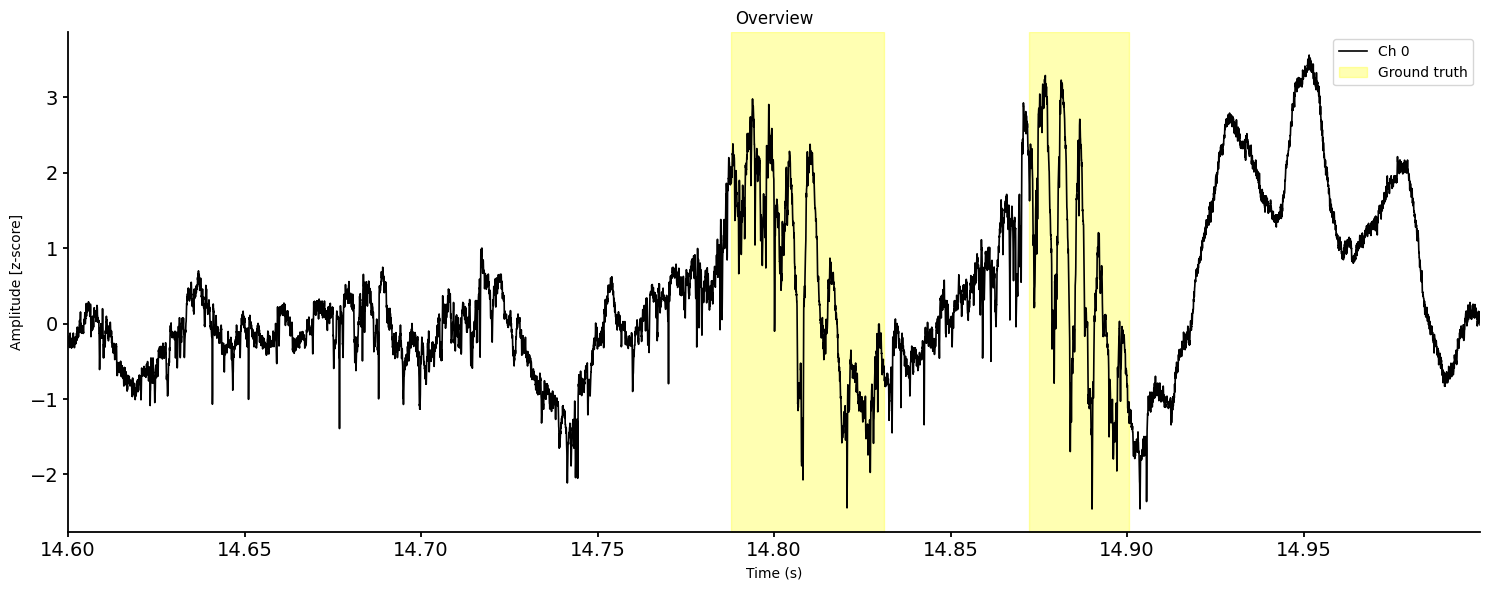

In [29]:
plot_offline_detections(liset,ch=0,plot_offline=False,plot_light=False,plot_predicted=False, window=(14.6,15))